# Análisis de startups LATAM

En este notebook vamos a explorar un dataset de aproximadamente **150 startups de América Latina**, repasando las herramientas de Python: carga de datos, exploración inicial y visualización básica.

El foco está en entender **qué hace cada instrucción** y **cómo interpretar los resultados** para tomar decisiones a partir de los datos.

---

**Columnas principales del dataset**
| Columna | Descripción |
|---|---|
| `startup` | Nombre de la startup |
| `sector_principal` | Sector de la industria (SaaS, Fintech, etc.) |
| `sector_secundario` | Sector secundario (puede estar vacío) |
| `modelo_negocio` | B2B o B2C |
| `pais` | País de origen |
| `anio_fundacion` | Año en que fue fundada |
| `edad_empresa` | Años desde su fundación |
| `etapa` | Etapa de financiamiento (Pre-seed, Seed, Serie A, Serie B) |
| `empleados` | Cantidad de empleados |
| `clientes_activos` | Clientes activos actuales |
| `arr_millones` | Ingresos recurrentes anuales en millones de USD |
| `churn_mensual_pct` | Porcentaje de clientes que se van cada mes |
| `nps_score` | Net Promoter Score (satisfacción del cliente, de -100 a 100) |
| `fondeo_usd_mm` | Total de fondeo recibido en millones de USD |
| `runway_meses` | Meses de pista que le quedan con el fondeo actual |
| `unicornio` | Si la startup vale más de USD 1.000 millones |

## Instalación de librerías

Antes de empezar, verificamos que estén instaladas las tres librerías que vamos a usar:

- **`pandas`**: carga, manipulación y análisis de datos en tablas (DataFrames).
- **`matplotlib`**: base para hacer gráficos en Python.
- **`seaborn`**: capa sobre matplotlib orientada a gráficos estadísticos.

Nota: el flag `--quiet` solo sirve para ocultar el texto de instalación en la salida.

In [1]:
!pip install pandas matplotlib seaborn --quiet

## Importación de librerías

Las librerías se instalan una vez, pero se **importan en cada sesión**. Los alias (`pd`, `plt`, `sns`) son una convención habitual en la comunidad de Python.

**Pregunta para repasar Python:** ¿qué rol cumple cada una de estas librerías (`pandas`, `matplotlib`, `seaborn`) en un análisis de datos?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
# Parte 1: Carga y exploración inicial del dataset

El primer paso es **cargar los datos y revisar su estructura básica** antes de avanzar con cualquier análisis.

### `pd.read_csv()` — carga del dataset

`pd.read_csv()` lee un archivo `.csv` y lo convierte en un **DataFrame** (tabla con filas y columnas en Python).

- `index_col=0` indica que la primera columna (`#`) se usa como índice de filas y no como columna de datos.

**Pregunta para repasar Python/pandas:** sin ejecutar el código, ¿cómo escribirían la instrucción para leer un archivo `startups.csv` en un DataFrame llamado `df` y usar la primera columna como índice?

In [3]:
df = pd.read_csv('startups.csv', index_col=0)

### `.head()` — primeras filas

`.head()` muestra por defecto las **primeras 5 filas** del DataFrame. Es útil para tener una vista rápida de las columnas y de los tipos de valores.

**Pregunta para repasar Python/pandas:** con lo que recuerdan de pandas, ¿cómo imprimirían las primeras 5 filas del DataFrame `df`? ¿Y cómo cambiarían el código para ver las primeras 10 filas?

In [4]:
df.head()

,startup,sector_principal,sector_secundario,modelo_negocio,pais,anio_fundacion,edad_empresa,etapa,empleados,clientes_activos,arr_millones,churn_mensual_pct,nps_score,fondeo_usd_mm,runway_meses,unicornio
#,,,,,,,,,,,,,,,,
1,Mercadowave,SaaS,NaN,B2B,Brasil,2021,4,Seed,16,208,1.40,14.1,60.0,0.84,8.0,False
2,Paylink,AI/ML,SaaS,B2B,Peru,2020,5,Seed,18,174,2.35,9.9,30.0,NaN,15.0,False
3,Cloudster,E-commerce,NaN,B2B,Brasil,2019,6,Seed,16,246,1.18,10.4,NaN,1.27,11.0,False
4,Datafy,Healthtech,NaN,B2B,Argentina,2022,3,Seed,10,180,0.86,NaN,34.0,NaN,12.0,False
5,Nexloop,Fintech,NaN,B2C,Argentina,2020,5,Seed,18,21,1.19,NaN,27.0,NaN,14.0,False


### `.tail()` — últimas filas

`.tail()` es el complemento de `.head()` y muestra las últimas filas del DataFrame. Sirve, por ejemplo, para verificar cómo terminan los datos o si hubo cortes extraños en la carga.

**Pregunta para repasar análisis exploratorio:** ¿en qué tipo de situaciones elegirían mirar primero `.tail()` en lugar de `.head()`?

In [5]:
df.tail()

,startup,sector_principal,sector_secundario,modelo_negocio,pais,anio_fundacion,edad_empresa,etapa,empleados,clientes_activos,arr_millones,churn_mensual_pct,nps_score,fondeo_usd_mm,runway_meses,unicornio
#,,,,,,,,,,,,,,,,
146,Upsello,AI/ML,NaN,B2B2C,Colombia,2021,4,Seed,14,128,2.50,8.5,27.0,1.08,25.0,False
147,Schedulix,E-commerce,Healthtech,B2C,Mexico,2021,4,Pre-seed,6,4,0.24,8.7,NaN,0.25,7.0,False
148,Marketix,SaaS,NaN,B2C,USA,2021,4,Pre-seed,6,21,0.27,NaN,12.0,0.13,NaN,False
149,Invoicex,Healthtech,SaaS,B2C,Argentina,2017,8,Serie A,3,546,7.49,5.5,44.0,NaN,27.0,False
150,Auditbase,Logistics,SaaS,B2C,USA,2022,3,Pre-seed,10,7,0.24,16.0,NaN,NaN,NaN,False


### `.shape` — dimensiones del DataFrame

`.shape` devuelve una tupla `(filas, columnas)` con la cantidad de registros y de variables.

Es un **atributo** del DataFrame (no lleva paréntesis), a diferencia de los métodos que sí se llaman con `()`. 

**Pregunta para repasar Python/pandas:** si `df` es un DataFrame, ¿cómo accederían solo al número de filas usando `.shape`?

In [6]:
print(f"El dataset tiene {df.shape[0]} startups y {df.shape[1]} variables")
df.shape

El dataset tiene 150 startups y 16 variables


(150, 16)

### `.info()` — resumen técnico del DataFrame

`.info()` es un método clave al explorar un dataset nuevo. Muestra, entre otras cosas:
1. **Tipo de dato** de cada columna (`int64`, `float64`, `object`, `bool`).
2. **Cantidad de valores no nulos** por columna (permite detectar valores faltantes).
3. **Uso de memoria** del DataFrame.

**Pregunta para repasar análisis exploratorio:** mirando el resultado de `.info()`, ¿cómo identificarían qué columnas tienen valores faltantes?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   startup            150 non-null    object 
 1   sector_principal   150 non-null    object 
 2   sector_secundario  73 non-null     object 
 3   modelo_negocio     150 non-null    object 
 4   pais               150 non-null    object 
 5   anio_fundacion     150 non-null    int64  
 6   edad_empresa       150 non-null    int64  
 7   etapa              150 non-null    object 
 8   empleados          150 non-null    int64  
 9   clientes_activos   150 non-null    int64  
 10  arr_millones       150 non-null    float64
 11  churn_mensual_pct  117 non-null    float64
 12  nps_score          123 non-null    float64
 13  fondeo_usd_mm      108 non-null    float64
 14  runway_meses       125 non-null    float64
 15  unicornio          150 non-null    bool   
dtypes: bool(1), float64(5), int64(4

### `.describe()` — estadísticas descriptivas

`.describe()` calcula automáticamente las estadísticas principales de **todas las columnas numéricas**:

| Estadística | Qué significa |
|---|---|
| `count` | Cantidad de valores no nulos |
| `mean` | Promedio |
| `std` | Desviación estándar (medida de dispersión) |
| `min` / `max` | Valor mínimo y máximo |
| `25%` / `50%` / `75%` | Percentiles (cuartiles) |

**Pregunta para repasar análisis descriptivo:** si para una variable el `mean` y el `50%` (mediana) son muy distintos, ¿qué indica eso sobre la distribución de los datos?

In [8]:
df.describe()

,anio_fundacion,edad_empresa,empleados,clientes_activos,arr_millones,churn_mensual_pct,nps_score,fondeo_usd_mm,runway_meses
count,150.000000,150.000000,150.000000,150.000000,150.000000,117.000000,123.000000,108.000000,125.000000
mean,2019.740000,5.260000,34.226667,591.726667,3.330467,9.392308,34.495935,4.031574,18.248000
std,2.031398,2.031398,43.252210,1089.909502,4.067363,4.868763,18.567720,6.163434,8.102823
min,2015.000000,2.000000,1.000000,1.000000,0.000000,2.400000,-42.000000,0.050000,1.000000
25%,2018.250000,4.000000,10.000000,76.250000,0.712500,6.000000,24.500000,0.580000,13.000000
50%,2020.000000,5.000000,17.500000,183.500000,1.860000,8.700000,34.000000,0.970000,18.000000
75%,2021.000000,6.750000,43.000000,601.250000,4.310000,12.000000,46.500000,4.992500,24.000000
max,2023.000000,10.000000,211.000000,9200.000000,18.500000,38.500000,92.000000,25.940000,46.000000


---
# Parte 2: Análisis de valores nulos

Antes de graficar, conviene revisar si el dataset tiene valores faltantes. Los nulos (`NaN`) pueden afectar cálculos y visualizaciones si no se manejan.

### `.isnull().sum()` — contar valores faltantes por columna

Se encadenan dos métodos:
- `.isnull()` devuelve un DataFrame de `True`/`False` según si el valor es nulo
- `.sum()` suma los `True` por columna (en Python, `True` equivale a 1 y `False` a 0)

El resultado es la cantidad de nulos por columna.

**Pregunta para repasar Python/pandas:** ¿cómo escribirían el código para contar cuántos valores nulos hay en cada columna del DataFrame `df`?

In [9]:
nulos = df.isnull().sum()
print("Columnas con valores faltantes:")
nulos[nulos > 0]

Columnas con valores faltantes:


sector_secundario    77
churn_mensual_pct    33
nps_score            27
fondeo_usd_mm        42
runway_meses         25
dtype: int64

### Porcentaje de nulos

El número absoluto de nulos no siempre basta. Un 5% suele ser manejable; un 40% puede ser problemático.

Se calcula dividiendo la cantidad de nulos por el total de filas (`len(df)`) y multiplicando por 100.

**Pregunta para repasar análisis:** ¿a partir de qué porcentaje de nulos considerarían que una columna pierde utilidad para el análisis?

In [10]:
pct_nulos = (df.isnull().sum() / len(df) * 100).round(1)
print("Porcentaje de nulos por columna:")
pct_nulos[pct_nulos > 0]

Porcentaje de nulos por columna:


sector_secundario    51.3
churn_mensual_pct    22.0
nps_score            18.0
fondeo_usd_mm        28.0
runway_meses         16.7
dtype: float64

---
# Parte 3: Análisis de variables categóricas

Las variables categóricas tienen **categorías o etiquetas** en lugar de números (sector, país, etapa, modelo de negocio). El primer paso es contar cuántos registros hay en cada categoría.

### `.value_counts()` — frecuencia de cada categoría

`.value_counts()` cuenta cuántas veces aparece cada valor único en una columna. Los resultados vienen ordenados de mayor a menor.

**Pregunta para repasar Python/pandas:** si tienen una columna `sector_principal` en el DataFrame `df`, ¿cómo obtendrían la cantidad de startups por sector?

In [11]:
print("Distribución por sector:")
print(df['sector_principal'].value_counts())
print()
print("Distribución por país:")
print(df['pais'].value_counts())
print()
print("Distribución por etapa:")
print(df['etapa'].value_counts())

Distribución por sector:
sector_principal
SaaS             37
Fintech          30
E-commerce       23
Healthtech       18
AI/ML            15
Cybersecurity    10
Edtech           10
Logistics         7
Name: count, dtype: int64

Distribución por país:
pais
Argentina    36
Mexico       24
Brasil       23
USA          21
Colombia     18
Chile        12
Uruguay       9
Peru          7
Name: count, dtype: int64

Distribución por etapa:
etapa
Seed        65
Serie A     38
Pre-seed    29
Serie B     18
Name: count, dtype: int64


### `.nunique()` — cantidad de valores únicos

A diferencia de `.value_counts()`, que da el conteo por valor, `.nunique()` devuelve solo **cuántos valores distintos** hay en la columna. Sirve para ver la cardinalidad antes de graficar.

**Pregunta para repasar Python/pandas:** ¿qué diferencia hay entre `.value_counts()` y `.nunique()`? ¿Cuándo usarían cada uno?

In [12]:
# .nunique() en todo el DataFrame nos da el conteo de únicos por columna
df.nunique()

startup              142
sector_principal       8
sector_secundario      8
modelo_negocio         3
pais                   8
anio_fundacion         9
edad_empresa           9
etapa                  4
empleados             65
clientes_activos     127
arr_millones         127
churn_mensual_pct     76
nps_score             59
fondeo_usd_mm         83
runway_meses          33
unicornio              2
dtype: int64

### Visualización: startups por sector

El resultado de `.value_counts()` se pasa a `sns.barplot()` para graficar barras. Parámetros útiles: `figsize` (tamaño), `palette` (colores), `plt.xticks(rotation=30)` (rotar etiquetas del eje X).

**Pregunta para repasar Python:** cuando usamos `conteo_sector.index` y `conteo_sector.values` en el barplot, ¿qué contiene cada uno? ¿Por qué los usamos por separado?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/1137618350.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_sector.index, y=conteo_sector.values, palette='viridis')


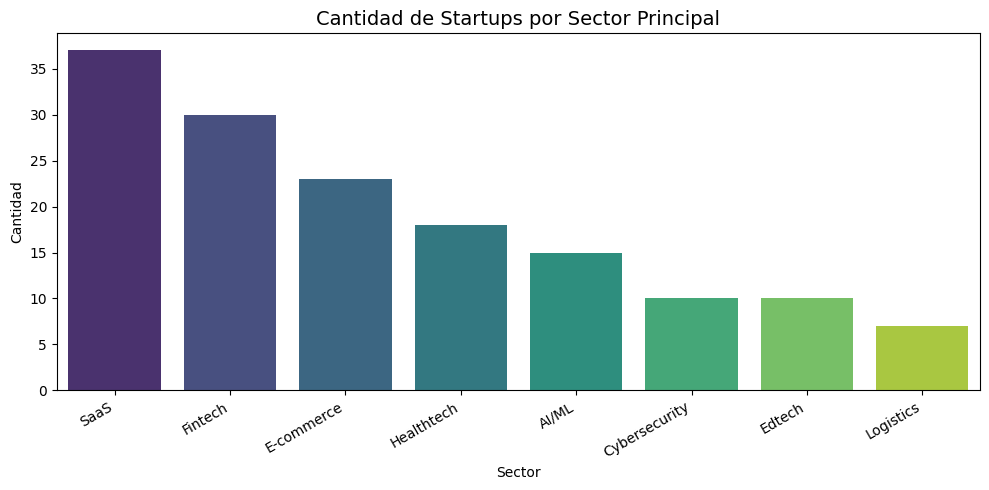

In [13]:
conteo_sector = df['sector_principal'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_sector.index, y=conteo_sector.values, palette='viridis')
plt.title('Cantidad de Startups por Sector Principal', fontsize=14)
plt.xlabel('Sector')
plt.ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Visualización: startups por país

Mismo patrón que el gráfico por sector: `.value_counts()` + `sns.barplot()`. La estructura se puede reutilizar para cualquier variable categórica.

**Pregunta para repasar análisis:** mirando el gráfico, ¿qué hipótesis podrían plantear sobre la distribución de startups por país?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/3017063155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_pais.index, y=conteo_pais.values, palette='mako')


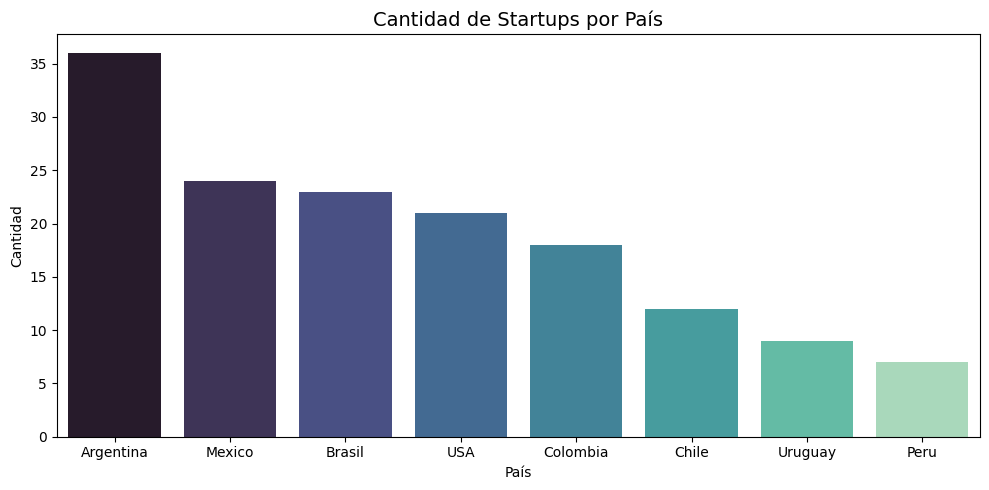

In [14]:
conteo_pais = df['pais'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_pais.index, y=conteo_pais.values, palette='mako')
plt.title('Cantidad de Startups por País', fontsize=14)
plt.xlabel('País')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

### Visualización: startups por etapa de financiamiento

Se usa `.reindex()` para **ordenar las etapas de forma lógica** (Pre-seed → Seed → Serie A → Serie B) en lugar de por frecuencia. El orden se guarda en `orden_etapas` para reutilizarlo en otros gráficos.

**Pregunta para repasar análisis:** ¿por qué suele haber más startups en Seed que en Serie B? ¿Qué implica eso para el ecosistema?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/1690946828.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_etapa.index, y=conteo_etapa.values, palette='rocket')


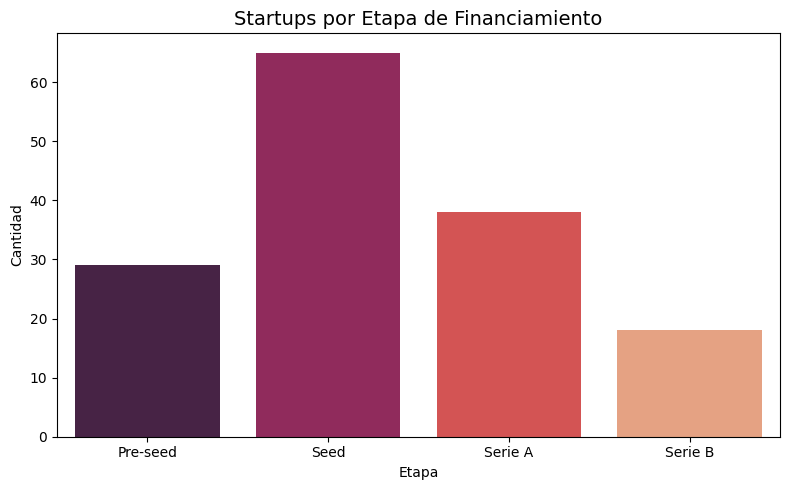

In [15]:
# Definimos el orden lógico de las etapas — lo reutilizamos varias veces
orden_etapas = ['Pre-seed', 'Seed', 'Serie A', 'Serie B']

conteo_etapa = df['etapa'].value_counts().reindex(orden_etapas)

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_etapa.index, y=conteo_etapa.values, palette='rocket')
plt.title('Startups por Etapa de Financiamiento', fontsize=14)
plt.xlabel('Etapa')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

---
# Parte 4: Análisis de variables numéricas

Se analizan las métricas de negocio: ARR, fondeo, churn, NPS, runway. Los gráficos permiten explorar distribuciones y comparar grupos.

### Histograma del ARR

Un histograma muestra la **distribución** de una variable numérica: concentración de valores, outliers, simetría o sesgo. Parámetros: `kde=True` (curva de densidad), `bins` (número de intervalos), `.dropna()` para excluir nulos antes de graficar.

**Pregunta para repasar análisis:** si la distribución del ARR está muy sesgada, ¿qué implicaría eso para el promedio frente a la mediana?

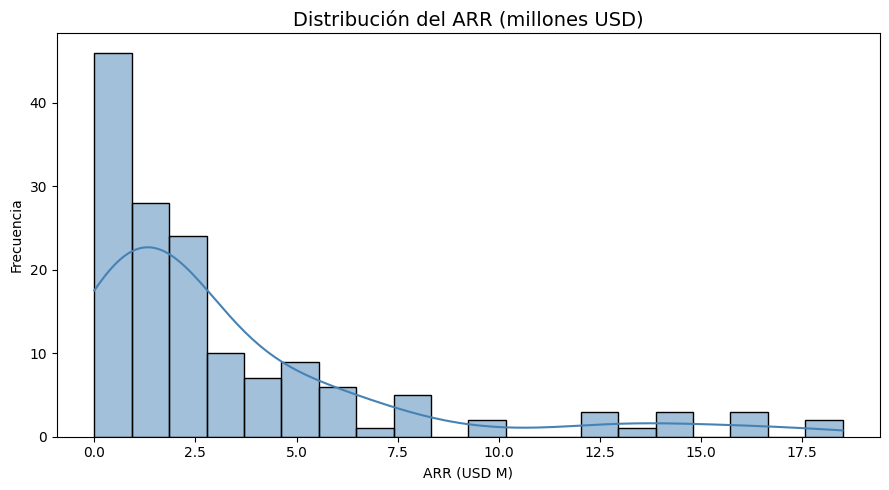

In [16]:
plt.figure(figsize=(9, 5))
sns.histplot(df['arr_millones'].dropna(), bins=20, kde=True, color='steelblue')
plt.title('Distribución del ARR (millones USD)', fontsize=14)
plt.xlabel('ARR (USD M)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### ARR por sector — boxplot

El **boxplot** sirve para comparar distribuciones entre grupos. Muestra la caja (percentiles 25–75), la mediana, los bigotes y los outliers. Los sectores se ordenan por mediana descendente para facilitar la lectura.

**Pregunta para repasar visualización:** ¿qué ventaja tiene un boxplot frente a un barplot de promedios cuando hay outliers o distribuciones muy distintas?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/2275932331.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


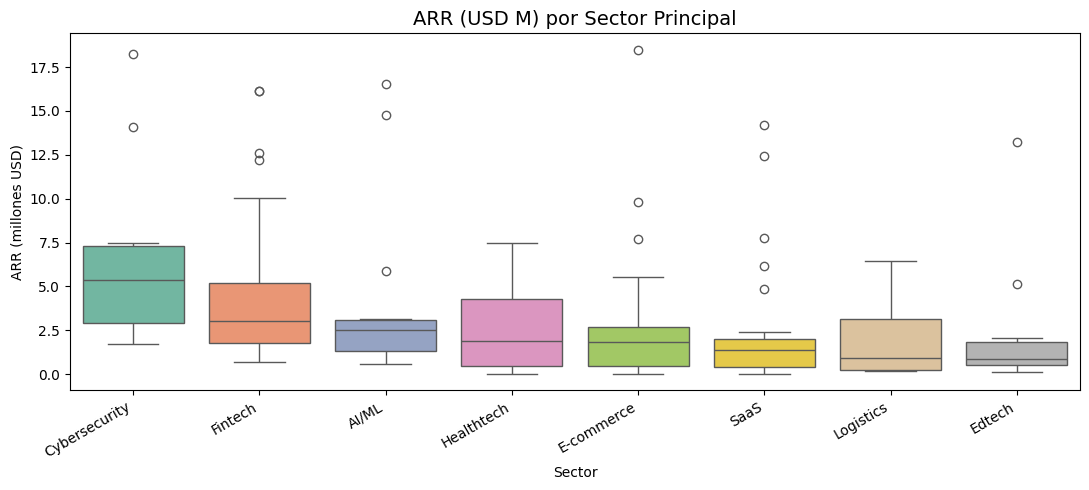

In [17]:
# Ordenamos los sectores por mediana de ARR de mayor a menor
orden_sectores = df.groupby('sector_principal')['arr_millones'].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 5))
sns.boxplot(
    data=df,
    x='sector_principal',
    y='arr_millones',
    order=orden_sectores,
    palette='Set2'
)
plt.title('ARR (USD M) por Sector Principal', fontsize=14)
plt.xlabel('Sector')
plt.ylabel('ARR (millones USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### `.groupby()` — agrupar y calcular estadísticas por categoría

`.groupby()` agrupa filas según una columna categórica y permite aplicar funciones de agregación (suma, promedio, máximo, etc.) a columnas numéricas. La idea: **agrupar por X, calcular Y**.

- `.groupby('etapa')` forma un grupo por cada etapa
- `['fondeo_usd_mm']` selecciona la columna
- `.mean()` calcula el promedio en cada grupo

**Pregunta para repasar Python/pandas:** ¿cómo escribirían el código para obtener el fondeo promedio por país? ¿Y el ARR máximo por sector?

In [18]:
# .groupby() agrupa por etapa y .mean() calcula el promedio de fondeo en cada grupo
fondeo_por_etapa = df.groupby('etapa')['fondeo_usd_mm'].mean().reindex(orden_etapas).round(2)
print("Fondeo promedio por etapa (USD M):")
fondeo_por_etapa

Fondeo promedio por etapa (USD M):


etapa
Pre-seed     0.15
Seed         1.29
Serie A      4.80
Serie B     18.33
Name: fondeo_usd_mm, dtype: float64

### Fondeo promedio por etapa — barplot

Se visualiza el resultado del `.groupby()`. En general, el fondeo aumenta con la etapa, ya que las rondas más avanzadas implican montos mayores.

**Pregunta para repasar análisis:** mirando el gráfico, ¿el crecimiento del fondeo entre etapas es gradual o hay saltos marcados?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/1498736503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fondeo_por_etapa.index, y=fondeo_por_etapa.values, palette='flare')


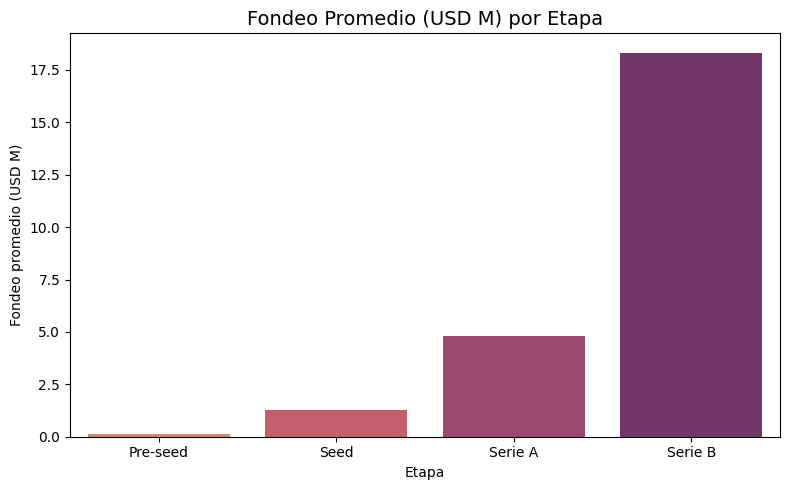

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x=fondeo_por_etapa.index, y=fondeo_por_etapa.values, palette='flare')
plt.title('Fondeo Promedio (USD M) por Etapa', fontsize=14)
plt.xlabel('Etapa')
plt.ylabel('Fondeo promedio (USD M)')
plt.tight_layout()
plt.show()

### Churn mensual por etapa — boxplot

El churn (tasa de cancelación) es una métrica clave. Un churn alto indica que se pierden clientes más rápido de lo que se ganan. El boxplot permite comparar el churn entre etapas.

**Pregunta para repasar análisis:** ¿esperarían que startups más maduras (Serie B) tengan mayor o menor churn que las de Pre-seed? ¿Por qué?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/3295827060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


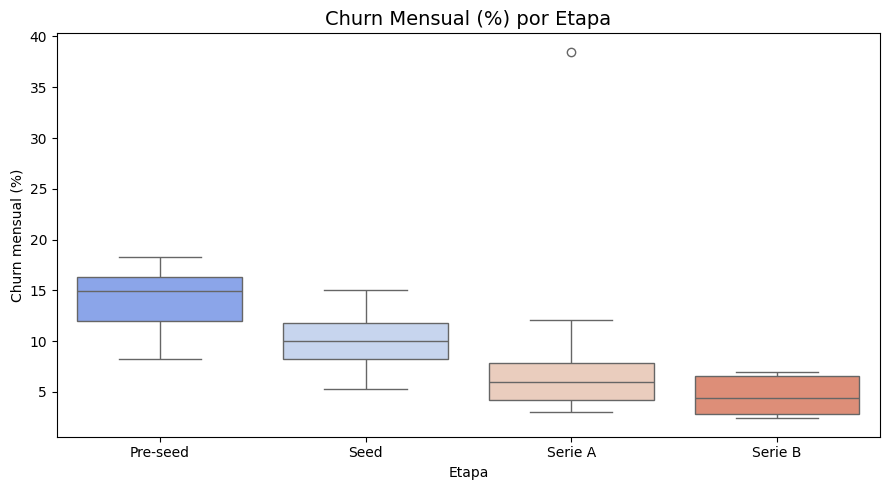

In [20]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='etapa',
    y='churn_mensual_pct',
    order=orden_etapas,
    palette='coolwarm'
)
plt.title('Churn Mensual (%) por Etapa', fontsize=14)
plt.xlabel('Etapa')
plt.ylabel('Churn mensual (%)')
plt.tight_layout()
plt.show()

### NPS promedio por país

El NPS (Net Promoter Score) mide la probabilidad de que un cliente recomiende el producto (-100 a 100; arriba de 50 suele considerarse excelente). Se usa `.groupby()`, `.mean()` y `.sort_values()` para ordenar países. `plt.axhline()` dibuja una línea de referencia (por ejemplo, el umbral 50).

**Pregunta para repasar análisis:** ¿un NPS promedio más alto en un país implica necesariamente mejor producto, o podrían influir otros factores?

/var/folders/nz/2nwf40qd06951mskmhzlp3t00000gq/T/ipykernel_3412/3449107247.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_pais.index, y=nps_pais.values, palette='Blues_d')


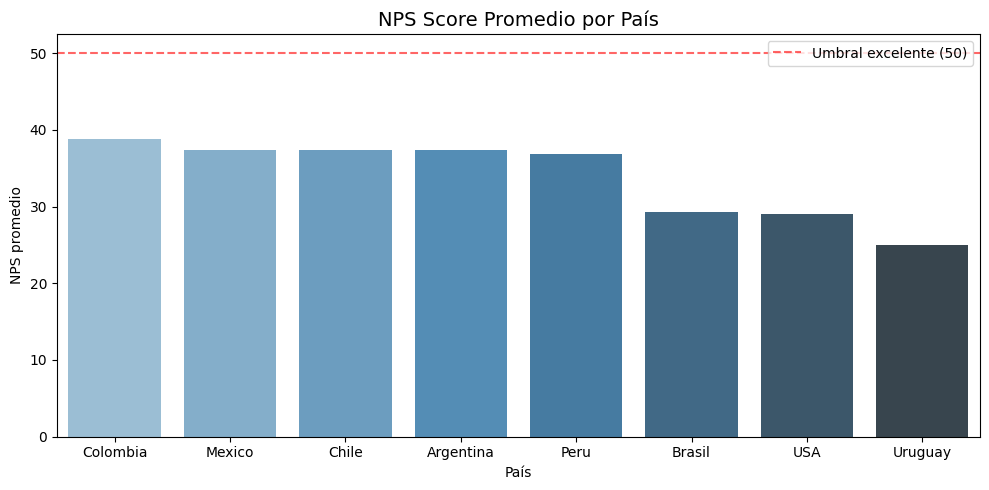

In [21]:
nps_pais = df.groupby('pais')['nps_score'].mean().sort_values(ascending=False).round(1)

plt.figure(figsize=(10, 5))
sns.barplot(x=nps_pais.index, y=nps_pais.values, palette='Blues_d')
plt.title('NPS Score Promedio por País', fontsize=14)
plt.xlabel('País')
plt.ylabel('NPS promedio')
# Línea de referencia en 50 (umbral "excelente")
plt.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Umbral excelente (50)')
plt.legend()
plt.tight_layout()
plt.show()

---
# Parte 5: Relaciones entre variables

Hasta ahora se analizaron variables por separado. Aquí se explora **cómo se relacionan entre sí** mediante scatter plots y líneas de tendencia.

### Scatter plot: ARR vs fondeo

`sns.scatterplot()` dibuja un punto por startup (fondeo en X, ARR en Y). El color (`hue`) puede indicar la etapa. Parámetros: `alpha` (transparencia), `s` (tamaño de puntos).

**Pregunta para repasar Python/visualización:** ¿cómo harían un scatter plot con `df` usando `fondeo_usd_mm` en el eje X y `arr_millones` en el eje Y?

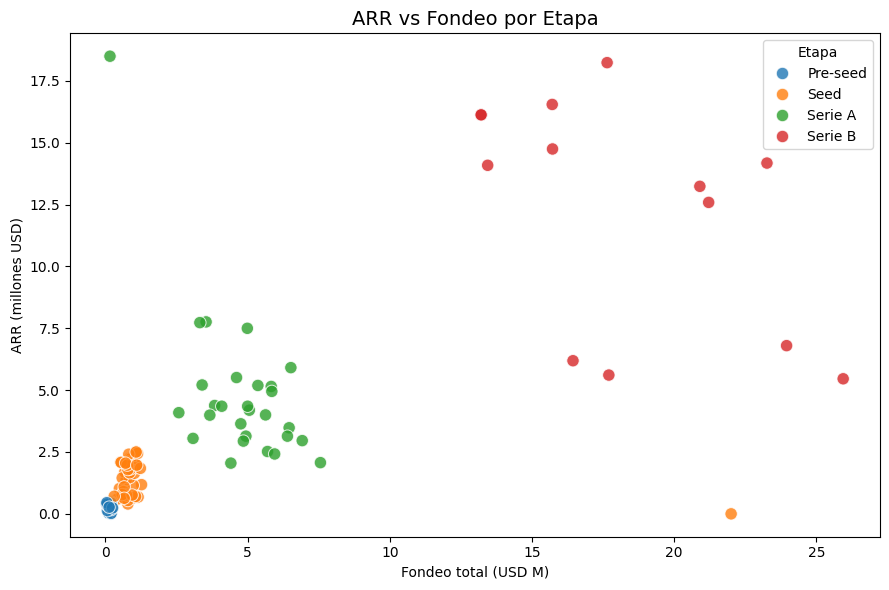

In [22]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='fondeo_usd_mm',
    y='arr_millones',
    hue='etapa',              # color según la etapa
    hue_order=orden_etapas,
    palette='tab10',
    alpha=0.8,
    s=80
)
plt.title('ARR vs Fondeo por Etapa', fontsize=14)
plt.xlabel('Fondeo total (USD M)')
plt.ylabel('ARR (millones USD)')
plt.legend(title='Etapa')
plt.tight_layout()
plt.show()

### Scatter plot con línea de tendencia: Churn vs NPS

¿Las startups con mayor satisfacción (NPS alto) retienen mejor a sus clientes (churn bajo)? Se puede explorar con un scatter y añadir `sns.regplot()` para la línea de regresión. Con `scatter=False` solo se dibuja la línea.

**Pregunta para repasar análisis:** mirando el gráfico, ¿la relación entre NPS y churn es fuerte o hay mucho ruido alrededor de la línea?

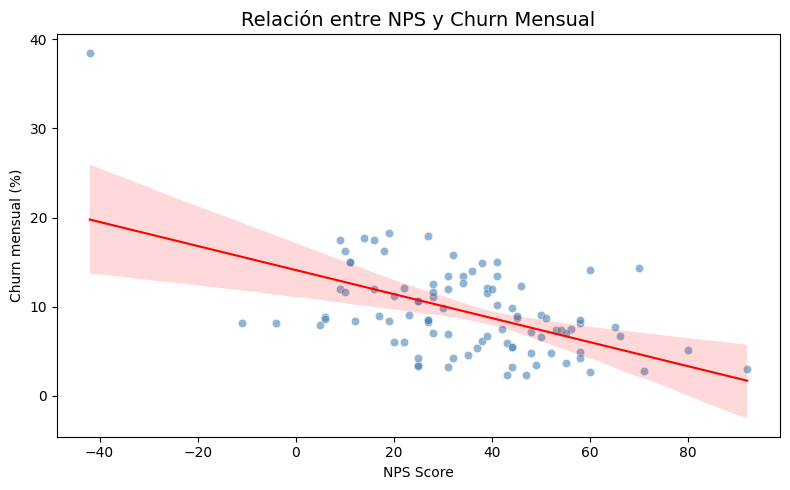

In [23]:
# .dropna() elimina filas donde alguna de las dos columnas es nula
df_limpio = df[['churn_mensual_pct', 'nps_score']].dropna()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_limpio, x='nps_score', y='churn_mensual_pct', alpha=0.6, color='steelblue')
# regplot agrega la línea de tendencia
sns.regplot(data=df_limpio, x='nps_score', y='churn_mensual_pct',
            scatter=False, color='red', line_kws={'linewidth': 1.5})
plt.title('Relación entre NPS y Churn Mensual', fontsize=14)
plt.xlabel('NPS Score')
plt.ylabel('Churn mensual (%)')
plt.tight_layout()
plt.show()

---
# Parte 6: Filtrado de datos — unicornios

El filtrado condicional en pandas permite seleccionar **solo las filas que cumplen una condición**. La sintaxis es `df[condición]`.

### Filtrado booleano

`df['unicornio'] == True` genera una Serie de `True`/`False`. Al pasarla entre corchetes al DataFrame, actúa como filtro y devuelve solo las filas donde la condición es `True`.

**Pregunta para repasar Python/pandas:** ¿cómo filtrarían las startups con ARR mayor a 10 millones? ¿Y las que son de Argentina **y** están en Serie B (dos condiciones a la vez)?

In [24]:
# Filtramos solo los unicornios
unicornios = df[df['unicornio'] == True]

print(f"Hay {len(unicornios)} unicornios en el dataset:\n")
unicornios[['startup', 'pais', 'sector_principal', 'etapa', 'arr_millones', 'fondeo_usd_mm', 'empleados']]

Hay 5 unicornios en el dataset:



,startup,pais,sector_principal,etapa,arr_millones,fondeo_usd_mm,empleados
#,,,,,,,
41,Predictly,Brasil,Fintech,Serie B,16.13,13.21,211
53,Subscriply,USA,AI/ML,Serie B,14.75,15.72,207
112,Partnerops,Argentina,Fintech,Serie B,5.04,NaN,28
128,Riskbase,Mexico,Cybersecurity,Serie B,14.09,13.44,111
145,Predictly,Brasil,Fintech,Serie B,16.13,13.21,211


### Comparación: unicornios vs el resto

Se usa `.groupby('unicornio')` para comparar métricas promedio entre ambos grupos. La columna booleana `unicornio` funciona como variable de agrupamiento — `True` y `False` son dos grupos distintos.

**Pregunta para repasar análisis:** mirando la tabla, ¿qué métrica difiere más entre unicornios y no-unicornios?

In [25]:
columnas_clave = ['arr_millones', 'fondeo_usd_mm', 'empleados', 'clientes_activos',
                  'nps_score', 'churn_mensual_pct', 'runway_meses']

df.groupby('unicornio')[columnas_clave].mean().round(2)

,arr_millones,fondeo_usd_mm,empleados,clientes_activos,nps_score,churn_mensual_pct,runway_meses
unicornio,,,,,,,
False,2.99,3.65,30.11,531.83,34.07,9.48,17.83
True,13.23,13.90,153.60,2328.80,47.25,4.50,30.75


---
# Parte 7: Correlaciones — matriz de calor

La **correlación** mide qué tan relacionadas están dos variables numéricas:
- `1.0` → correlación positiva perfecta
- `-1.0` → correlación negativa perfecta
- `0.0` → sin correlación lineal

`.corr()` calcula la correlación entre **todas las combinaciones** de columnas numéricas a la vez.

### `.corr()` — matriz de correlación

Se seleccionan las columnas numéricas y se calcula la matriz con `.corr()`. Cada celda muestra la correlación entre dos columnas. La diagonal vale siempre `1.0` (correlación de una variable consigo misma).

**Pregunta para repasar Python/pandas:** ¿cómo escribirían el código para calcular la matriz de correlación de las columnas numéricas de `df`?

In [26]:
numericas = ['edad_empresa', 'empleados', 'clientes_activos', 'arr_millones',
             'churn_mensual_pct', 'nps_score', 'fondeo_usd_mm', 'runway_meses']

# .corr() calcula el coeficiente de correlación de Pearson entre todos los pares
corr = df[numericas].corr()
corr.round(2)

,edad_empresa,empleados,clientes_activos,arr_millones,churn_mensual_pct,nps_score,fondeo_usd_mm,runway_meses
edad_empresa,1.00,0.69,0.55,0.69,-0.46,0.50,0.64,0.73
empleados,0.69,1.00,0.63,0.78,-0.42,0.33,0.78,0.66
clientes_activos,0.55,0.63,1.00,0.60,0.05,0.08,0.63,0.56
arr_millones,0.69,0.78,0.60,1.00,-0.43,0.36,0.68,0.68
churn_mensual_pct,-0.46,-0.42,0.05,-0.43,1.00,-0.53,-0.40,-0.47
nps_score,0.50,0.33,0.08,0.36,-0.53,1.00,0.41,0.39
fondeo_usd_mm,0.64,0.78,0.63,0.68,-0.40,0.41,1.00,0.69
runway_meses,0.73,0.66,0.56,0.68,-0.47,0.39,0.69,1.00


### Heatmap de correlaciones

Un heatmap convierte la matriz de números en un mapa de colores. Parámetros: `annot=True` (mostrar números), `fmt='.2f'` (formato), `center=0` (centrar la paleta en 0), `linewidths` (separación entre celdas).

**Pregunta para repasar análisis:** mirando el heatmap, ¿qué par de variables tiene la correlación más fuerte (positiva o negativa)? ¿Tiene sentido desde el punto de vista del negocio?

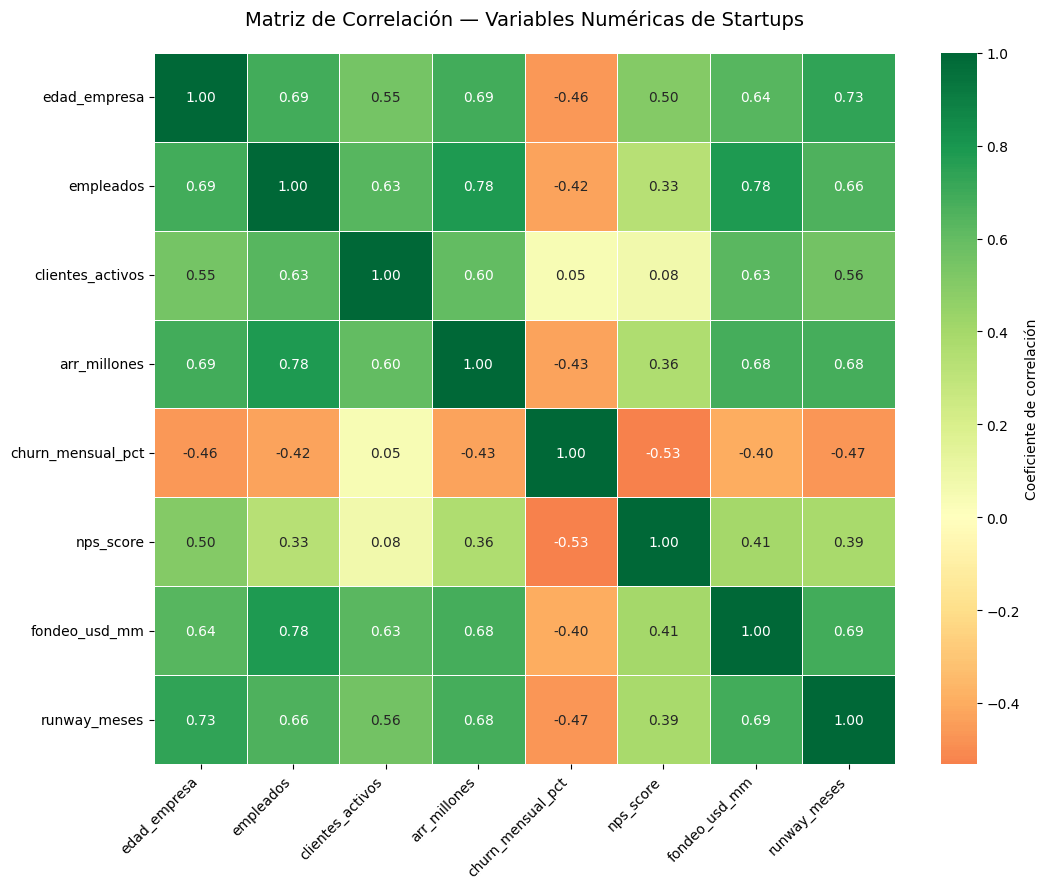

In [27]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación'}
)
plt.title('Matriz de Correlación — Variables Numéricas de Startups', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
# Parte 8: Resumen ejecutivo

Al final del análisis conviene resumir los hallazgos más importantes. Aquí se combina lo visto para generar un resumen con código.

### `.agg()` — múltiples estadísticas a la vez

`.agg()` permite calcular **varias estadísticas al mismo tiempo** para una o varias columnas. Se pasa una lista con los nombres de las funciones (por ejemplo, `['mean', 'median', 'max']`).

**Pregunta para repasar Python/pandas:** ¿cómo escribirían el código para calcular el promedio, la mediana y el máximo de `arr_millones` en una sola llamada?

In [28]:
print("=" * 55)
print("         RESUMEN DEL DATASET DE STARTUPS LATAM")
print("=" * 55)
print(f"  Total de startups analizadas : {len(df)}")
print(f"  Países representados         : {df['pais'].nunique()}")
print(f"  Sectores cubiertos           : {df['sector_principal'].nunique()}")
print(f"  Unicornios en el dataset     : {df['unicornio'].sum()}")
print()

# .agg() calcula varias estadísticas a la vez
resumen = df[['arr_millones', 'fondeo_usd_mm', 'churn_mensual_pct', 'nps_score', 'runway_meses']].agg(['mean', 'median', 'max']).round(2)
resumen.index = ['Promedio', 'Mediana', 'Máximo']
resumen

         RESUMEN DEL DATASET DE STARTUPS LATAM
  Total de startups analizadas : 150
  Países representados         : 8
  Sectores cubiertos           : 8
  Unicornios en el dataset     : 5



,arr_millones,fondeo_usd_mm,churn_mensual_pct,nps_score,runway_meses
Promedio,3.33,4.03,9.39,34.5,18.25
Mediana,1.86,0.97,8.70,34.0,18.00
Máximo,18.50,25.94,38.50,92.0,46.00


---

## Preguntas para repasar

1. Sin mirar el notebook: ¿qué métodos de pandas usamos hoy? Hagan una lista de los que recuerdan.
2. ¿Qué diferencia hay entre `.describe()` y `.agg()`? ¿Cuándo usarían cada uno?
3. ¿Qué diferencia hay entre `.value_counts()` y `.nunique()`?
4. Si tuvieran que agregar una nueva visualización, ¿qué pregunta de negocio querrían responder?
5. Antes de un análisis más avanzado, ¿qué harían con los valores nulos: eliminarlos con `.dropna()` o reemplazarlos (por ejemplo con la mediana)? ¿Depende del caso?
6. ¿Cómo extenderían este análisis para intentar predecir qué startups tienen más probabilidades de convertirse en unicornios?

---
*Dataset: Startups LATAM — 150 empresas | Variables: sector, país, etapa, ARR, churn, NPS, fondeo, runway*